In [1]:
import pandas as pd

In [2]:
!ls /usr/share/misc

abbrevs.gen.gz	 cities.dat.gz	 latin1.gz	  na.postalcodes.gz
abbrevs.talk.gz  countries.gz	 magic		  operator.gz
airport.gz	 currency.gz	 magic.mgc	  top-level.domains.gz
ascii.gz	 inter.phone.gz  mailinglists.gz  unicode.gz
birthtoken.gz	 languages.gz	 na.phone.gz


 See https://refspecs.linuxfoundation.org/FHS_3.0/fhs/ch04s11.html

## Airports

In [3]:
airport_df=pd.read_csv('/usr/share/misc/airport.gz',delimiter=':',skipfooter=2,engine='python')

In [4]:
airport_df

,# Airport Code,Airport,Country Code,Geographic subdivision,Major city or cities serving
0,AAL,Aalborg,DK,NaN,Aalborg
1,AAR,Aarhus,DK,NaN,Aarhus
2,ABD,Abadan,IR,NaN,Abadan
3,ABE,Lehigh Valley International Airport,US,PA,"Allentown, PA|Bethlehem, PA"
4,ABQ,Albuquerque International Sunport,US,NM,"Albuquerque, NM"
...,...,...,...,...,...
491,YYJ,Victoria Intl,CA,BC,"Victoria, BC"
492,YYZ,Lester B. Pearson International,CA,ON,"Toronto, ON"
493,ZAD,Zadar,HR,NaN,Zadar
494,ZAG,Zagreb Pleso,HR,NaN,Zagreb


according to Linux Cookbook by Michael Stutz, useful for querying National Weather Service computers. Hence the emphasis on US?

In [5]:
(airport_df
 .groupby('Country Code')
 .count()
 ['Airport']
 .count()
)

108

In [6]:
(airport_df
 .groupby('Country Code')
 .count()
 ['Airport']
 .sort_values(ascending=False)
 .iloc[0:35]
)

Country Code
US    155
IT     27
DE     22
TR     21
ES     17
CA     16
FR     15
GB     15
MX      9
JP      7
AT      6
RU      6
GR      6
PL      6
HR      5
IR      5
ZA      5
CH      5
BR      5
TH      5
AU      5
IN      4
NO      4
PT      4
DK      4
UA      4
EG      4
IE      3
AE      3
CU      3
DO      3
BG      3
PK      2
SA      2
RO      2
Name: Airport, dtype: int64

Hmm, 6 airports for russia?

<AxesSubplot: ylabel='Country Code'>

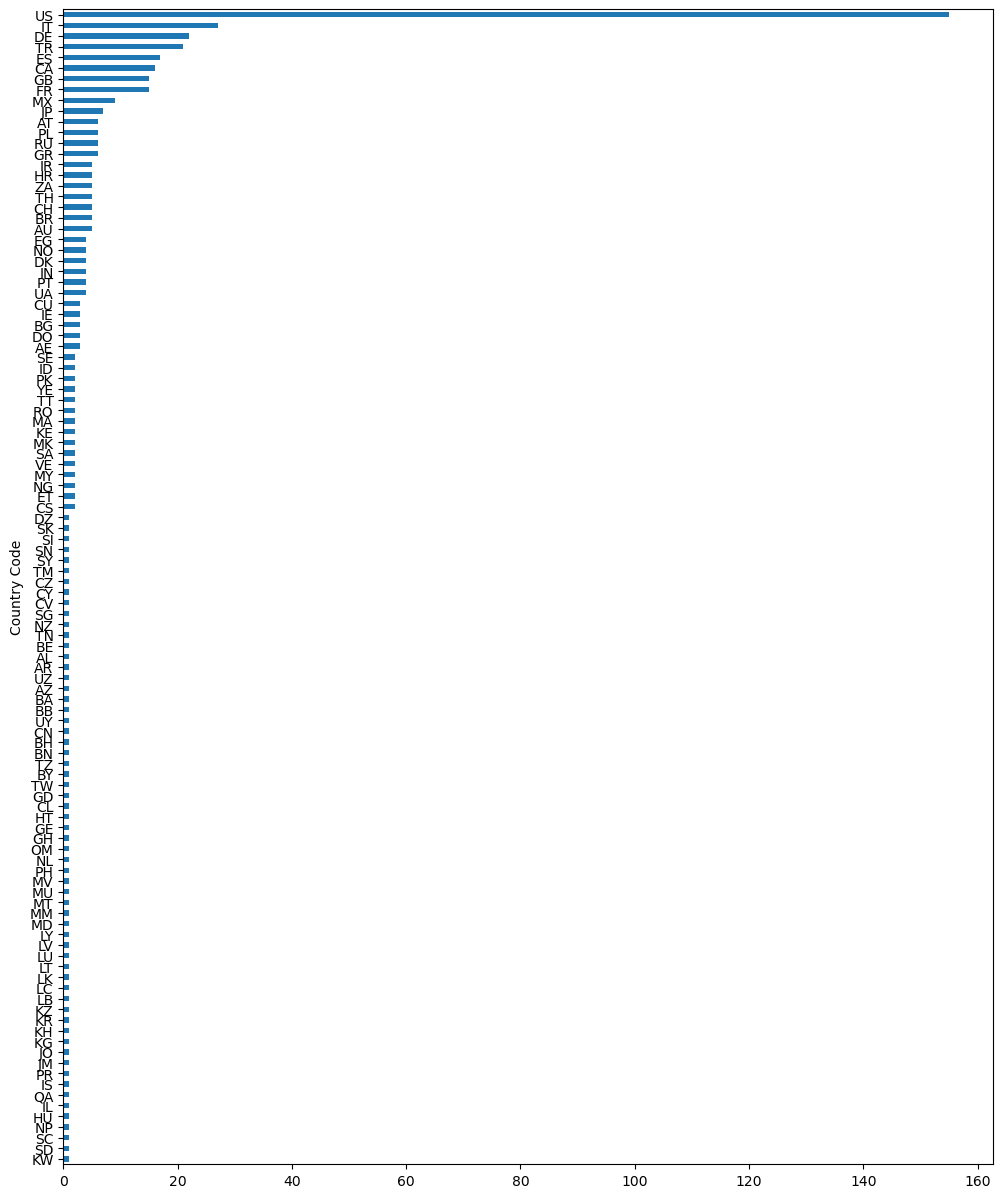

In [7]:
(airport_df
 .groupby('Country Code')
 .count()
 ['Airport']
 .sort_values()
 .plot(kind='barh',figsize=[12,15])
)

## Countries

In [8]:
countries_df=pd.read_csv('/usr/share/misc/countries.gz',delimiter=':',engine='python')

In [21]:
countries_df.rename({' 2 letter ISO abbrev ':'Country Code'},axis=1)

,# UN Code number,Country Code,3 letter ISO abbrev,name,capital
0,4,AF,AFG,Afghanistan,Kabul
1,248,AX,ALA,Åland Islands,Mariehamn
2,8,AL,ALB,Albania,Tirana
3,12,DZ,DZA,Algeria,Algiers
4,16,AS,ASM,American Samoa,Pago Pago
...,...,...,...,...,...
237,876,WF,WLF,Wallis and Futuna Islands,Mata-Utu
238,732,EH,ESH,Western Sahara,Laâyoune
239,887,YE,YEM,Yemen,Sanaa
240,894,ZM,ZMB,Zambia,Lusaka


In [19]:
countries_df.iloc[0].to_dict()

{'# UN Code number': 4,
 ' 2 letter ISO abbrev ': 'AF',
 ' 3 letter ISO abbrev ': 'AFG',
 ' name ': 'Afghanistan',
 ' capital': 'Kabul'}

In [23]:
joined_df=(airport_df
 .merge(
     countries_df
     .rename(
         columns={' 2 letter ISO abbrev ':'Country Code'}),
     on='Country Code')
)

In [24]:
joined_df

,# Airport Code,Airport,Country Code,Geographic subdivision,Major city or cities serving,# UN Code number,3 letter ISO abbrev,name,capital
0,AAL,Aalborg,DK,NaN,Aalborg,208,DNK,Denmark,Copenhagen
1,AAR,Aarhus,DK,NaN,Aarhus,208,DNK,Denmark,Copenhagen
2,BLL,Billund,DK,NaN,Billund,208,DNK,Denmark,Copenhagen
3,CPH,Copenhagen,DK,NaN,Copenhagen,208,DNK,Denmark,Copenhagen
4,ABD,Abadan,IR,NaN,Abadan,364,IRN,Iran,Tehran
...,...,...,...,...,...,...,...,...,...
497,YXU,London Municipal,CA,ON,"London, ON",124,CAN,Canada,Ottawa
498,YXY,Whitehorse,CA,YT,"Whitehorse, YT",124,CAN,Canada,Ottawa
499,YYC,Calgary International,CA,AB,"Calgary, AB",124,CAN,Canada,Ottawa
500,YYJ,Victoria Intl,CA,BC,"Victoria, BC",124,CAN,Canada,Ottawa


In [26]:
(joined_df
 .groupby(' name ')
 .count()
 ['Airport']
 .sort_values(ascending=False)
 .iloc[0:35]
)

 name 
United States of America                                155
Italy                                                    27
Germany                                                  22
Turkey                                                   21
Spain                                                    17
Canada                                                   16
United Kingdom of Great Britain and Northern Ireland     15
France                                                   15
Mexico                                                    9
Japan                                                     7
Russian Federation                                        6
Austria                                                   6
Poland                                                    6
Greece                                                    6
Croatia                                                   5
Switzerland                                               5
South Africa                     